In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [2]:
sussman2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq.RDS')
sussman2024

An object of class Seurat 
19152 features across 401253 samples within 1 assay 
Active assay: RNA (19152 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

In [3]:
sussman2024 <- subset(sussman2024, molecularClass %in% c(
'HGG - H3F3A K27M',
'HGG - NOS')
                     )
sussman2024

An object of class Seurat 
19152 features across 322559 samples within 1 assay 
Active assay: RNA (19152 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

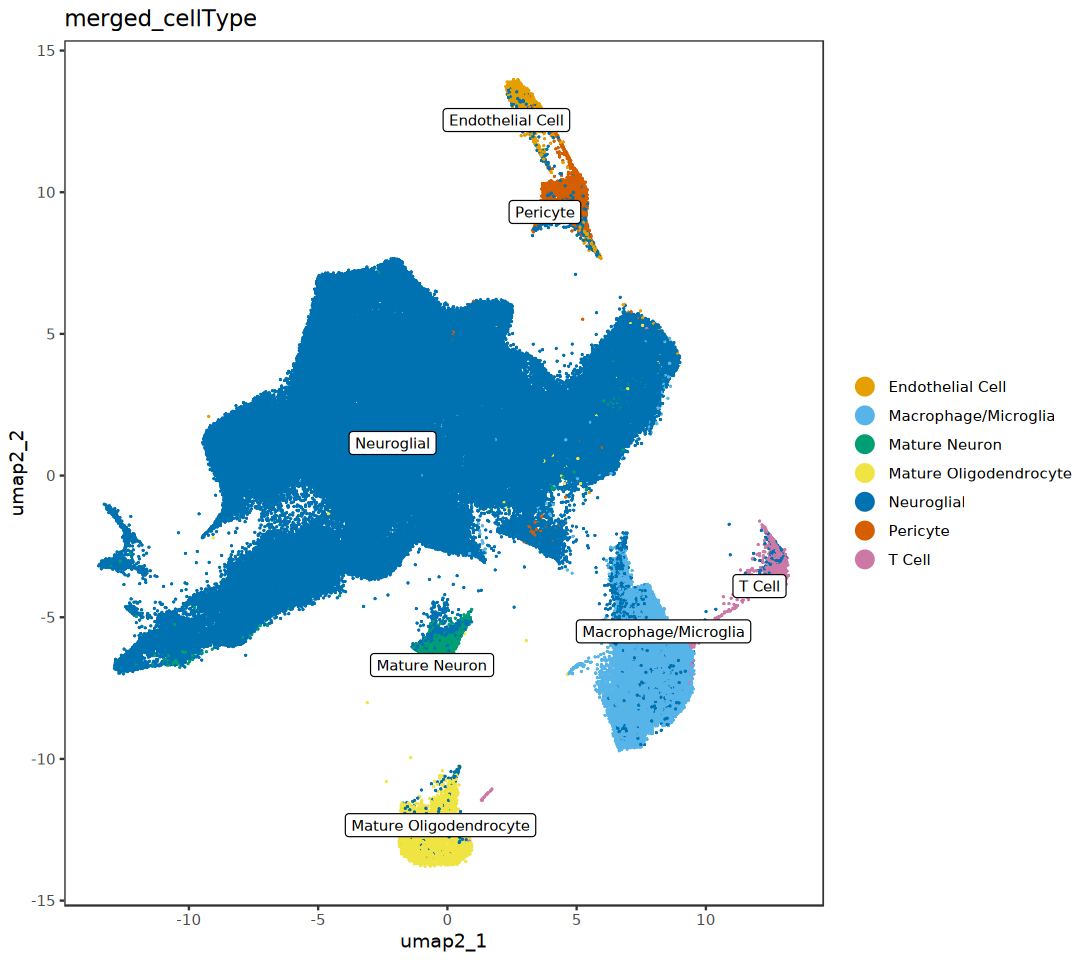

In [4]:
options(repr.plot.height = 8, repr.plot.width = 9)
dittoDimPlot(sussman2024, do.raster = TRUE,
             reduction.use = "umap", var = "merged_cellType", 
             do.label = T, labels.size = 3, size = 0.5)

In [5]:
sussman2024 <- sussman2024 %>% NormalizeData()%>%FindVariableFeatures()%>%
                ScaleData()%>%RunPCA(verbose = FALSE)

Centering and scaling data matrix



In [ ]:
saveRDS(sussman2024, '/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT.RDS')